<a href="https://colab.research.google.com/github/fernandolievano/procesamiento-del-habla/blob/main/PH_TP2_WebScraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico 2 - Web Scraping

Asignatura: Procesamiento del Habla

---

- Cree una nube de palabras de un texto en español.

- Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

- Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

- En este notebook explica el paso a paso del proceso.

### Setup Notebook

In [ ]:
!pip install requests beautifulsoup4 html5lib

In [40]:
import requests
import spacy
import re
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from collections import Counter
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# URL del discurso a scrappear
# Gabríel García Márquez - Premio Nobel en Literatura 1982
url = 'https://www.tesis11.org.ar/discurso-de-gabriel-garcia-marquez-de-aceptacion-del-premio-nobel-de-literatura-en-1982/'

# Timeout para try/except (segundos)
timeout = 5

In [ ]:
# instalamos el modelo en español
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 38.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Utils
def print_title(title):
    print('=' * 60)
    print(f' {title}')
    print('=' * 60)
    print('\n')

## 1. Web Scraping

Fetch de los datos y pequeñas validaciones

In [ ]:
try:
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()

    print('STATUS CODE: ', response.status_code)
    if response.status_code == 200:
        print('-> CONEXIÓN EXITOSA')
except requests.exceptions.Timeout:
    print('TIMEOUT ERROR \n')
    print(f'-> NO SE PUDO REALIZAR LA CONEXIÓN A {url}')
except requests.exceptions.ConnectionError:
    print('CONNECTION ERROR \n')
    print(f'-> NO SE PUDO REALIZAR LA CONEXIÓN A {url}')
except requests.exceptions.HTTPError as errh:
    print('HTTP ERROR \n')
    print("-> HUBO UN ERROR:", errh)

STATUS CODE:  200
-> CONEXIÓN EXITOSA


Parseamos el HTML que obtuvimos de la petición anterior.

In [ ]:
soup = BeautifulSoup(response.text, 'html.parser')

Ahora, en la web, identificamos el contenedor (HTML) del texto a trabajar.

En este caso, el discurso se encuentra dentro de un `<article>` con la clase `post`

In [ ]:
# elemento HTML donde se encuentra el texto solicitado
speech_container = soup.find('div', class_='entry-content')
# usamos .get_text() para obtener el texto crudo dentro del html
speech_container_text = speech_container.get_text()
print_title('HTML EXTRAÍDO:')
print(speech_container)
print('\n')


print_title('TEXTO EXTRAÍDO:')
print(speech_container_text)

 HTML EXTRAÍDO:


<div class="entry-content">
<div class="addtoany_share_save_container addtoany_content addtoany_content_top"><div class="addtoany_header">Compartir:</div><div class="a2a_kit a2a_kit_size_32 addtoany_list" data-a2a-title="Discurso de Gabriel Garcia Marquez de aceptación del Premio Nobel de Literatura en 1982" data-a2a-url="https://www.tesis11.org.ar/discurso-de-gabriel-garcia-marquez-de-aceptacion-del-premio-nobel-de-literatura-en-1982/"><a class="a2a_button_twitter" href="https://www.addtoany.com/add_to/twitter?linkurl=https%3A%2F%2Fwww.tesis11.org.ar%2Fdiscurso-de-gabriel-garcia-marquez-de-aceptacion-del-premio-nobel-de-literatura-en-1982%2F&amp;linkname=Discurso%20de%20Gabriel%20Garcia%20Marquez%20de%20aceptaci%C3%B3n%20del%20Premio%20Nobel%20de%20Literatura%20en%201982" rel="nofollow noopener" target="_blank" title="Twitter"></a><a class="a2a_button_whatsapp" href="https://www.addtoany.com/add_to/whatsapp?linkurl=https%3A%2F%2Fwww.tesis11.org.ar%2Fdiscurso-de-gabri

El discurso está extraído, pero todavía hay un texto "Compartir:Imprimir" correspondiente a un botón que hay que limpiar.

In [ ]:
cleaned_text = speech_container_text.replace('Compartir:Imprimir', '')

print_title('TEXTO LIMPIO:')
print(cleaned_text)

 TEXTO LIMPIO:




Antonio Pigafetta, un navegante florentino que acompañó a Magallanes en  el primer viaje alrededor del mundo, escribió a su paso por nuestra  América meridional una crónica rigurosa que sin embargo parece una  aventura de la imaginación. Contó que había visto cerdos con el ombligo  en el lomo, y unos pájaros sin patas cuyas hembras empollaban en las  espaldas del macho, y otros como alcatraces sin lengua cuyos picos  parecían una cuchara. Contó que había visto un engendro animal con  cabeza y orejas de mula, cuerpo de camello, patas de ciervo y relincho  de caballo. Contó que al primer nativo que encontraron en la Patagonia  le pusieron enfrente un espejo, y que aquel gigante enardecido perdió el  uso de la razón por el pavor de su propia imagen.
Este libro breve y fascinante, en el cual ya se vislumbran los gérmenes  de nuestras novelas de hoy, no es ni mucho menos el testimonios más  asombroso de nuestra realidad de aquellos tiempos. Los cronistas de  Indias nos le

## 2. Preprocesamiento

### Stopwords encontradas en el texto

In [ ]:
#cargar el modelo
nlp = spacy.load('es_core_news_sm')

# procesamos el texto limpio con spacy
doc = nlp(cleaned_text)

# identificamos las stopwords
found_stopwords = [token.text.lower() for token in doc if token.is_stop]

print_title('STOPWORDS ENCONTRADAS:')
if found_stopwords:
    print(f"-> Total de stopwords encontradas: {len(found_stopwords)}")
    print("Listado de stopwords: ", sorted(list(set(found_stopwords))))
    print('\n')
    print('\n')

    # listamos las stopwords más frecuentes
    print_title('STOPWORDS MÁS FRECUENTES:')
    stopword_counts = Counter(found_stopwords)
    for stopword, count in stopword_counts.most_common(10): # top 10
        print(f"'{stopword}': {count}")
else:
    print("No se encontraron stopwords en el texto.")

 STOPWORDS ENCONTRADAS:


-> Total de stopwords encontradas: 1390
Listado de stopwords:  ['a', 'ahora', 'al', 'alrededor', 'ante', 'antes', 'apenas', 'aquel', 'aquella', 'aquellos', 'aquí', 'así', 'aún', 'breve', 'buenas', 'cada', 'casi', 'cierto', 'cinco', 'como', 'con', 'contra', 'creo', 'cual', 'cuantos', 'cuatro', 'cuál', 'de', 'del', 'demasiado', 'desde', 'dieron', 'diferentes', 'dijo', 'donde', 'dos', 'durante', 'día', 'dónde', 'e', 'el', 'ello', 'ellos', 'embargo', 'en', 'enfrente', 'entonces', 'entre', 'era', 'es', 'esa', 'esas', 'ese', 'eso', 'esta', 'estaban', 'estado', 'estados', 'estas', 'este', 'esto', 'está', 'están', 'fin', 'fue', 'fuera', 'fueron', 'gran', 'grande', 'grandes', 'ha', 'haber', 'había', 'hace', 'hacen', 'hacer', 'han', 'hasta', 'hay', 'haya', 'hemos', 'hizo', 'hoy', 'junto', 'la', 'lado', 'las', 'le', 'lleva', 'lo', 'los', 'manera', 'mayor', 'me', 'medio', 'mejor', 'menos', 'menudo', 'mi', 'mientras', 'mis', 'misma', 'mismos', 'muchas', 'mucho', 'muchos', 

### Quitamos las stopwords, caracteres extraños del texto. Utilizamos el texto restante para crear una nube de palabras. Usamos la biblioteca worldcloud de python.

 NUBE DE PALABRAS:




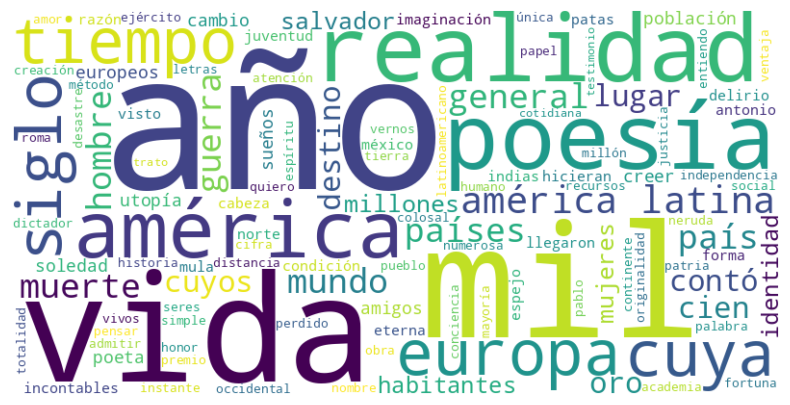

In [ ]:
# quitamos stopwords, signos de puntuación y caracteres extraños
filtered_words = []
for token in doc:
    if not token.is_stop and not token.is_punct and token.is_alpha:
        filtered_words.append(token.text.lower())

# unimos las palabras filtradas en una sola string
text_for_wordcloud = " ".join(filtered_words)

# generamos la nube de palabras
print_title('NUBE DE PALABRAS:')
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=set(nlp.Defaults.stop_words),
    min_font_size=10
).generate(text_for_wordcloud)

# graficamos la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### Limpiamos y preprocesamos el texto, lo descomponemos en oraciones y armamos una matriz documento-vocabulario.


In [ ]:
# 1. descomponemos el texto en oraciones
sentences = [sent.text.strip() for sent in doc.sents if sent.text.strip()]

print_title('ORACIONES EXTRAIDAS:')
for i, sent in enumerate(sentences[:5]): # Mostramos las primeras 5 oraciones
    print(f"-> Oración {i+1}: {sent}")
if len(sentences) > 5:
    print("...")
print(f"Total de oraciones: {len(sentences)} \n")

# 2. limpiamos y preprocesamos cada oración
# para eso, creamos una lista de listas
# donde cada sublista contiene las palabras limpias de una oración
cleaned_sentences_words = []
all_cleaned_words = []

for sentence_text in sentences:
    sentence_doc = nlp(sentence_text)
    # filtramos stopwords, signos de puntuación, caracteres extraños
    processed_words = [
        token.text.lower() for token in sentence_doc
        if not token.is_stop and not token.is_punct and token.is_alpha and len(token.text) > 2
    ]
    cleaned_sentences_words.append(processed_words)
    all_cleaned_words.extend(processed_words)

print_title('EJMPLO ORACIÓN PROCESADA:')
if cleaned_sentences_words:
    print(cleaned_sentences_words[0])
print('\n')

# 3. creamos el vocabulario (palabras únicas y ordenadas)
vocabulary = sorted(list(set(all_cleaned_words)))

print_title('Tamaño del vocabulario y primeras 10 palabras:')
print(f"-> Tamaño del vocabulario: {len(vocabulary)}")
print(f"-> Primeras 10 palabras del vocabulario: {vocabulary[:10]}\n")

# 4. Armamos la matriz documento-vocabulario (Bag of Words)

document_vocabulary_matrix = []
for cleaned_words_in_sentence in cleaned_sentences_words:
    # contamos la frecuencia de cada palabra en la oración
    word_counts = Counter(cleaned_words_in_sentence)

    # creamos un vector para la oración, con la frecuencia de cada palabra del vocabulario
    sentence_vector = [word_counts[word] for word in vocabulary]
    document_vocabulary_matrix.append(sentence_vector)

print_title('Matriz Documento-Vocabulario (oraciones y 10 palabras):')
# imprimimos la cabecera con las primeras palabras del vocabulario
header = "\t".join(vocabulary[:10])
print(f"Palabras:\t{header}")
print("-" * (len(header) + 10))

# imprimimos las primeras filas de la matriz
for i, row in enumerate(document_vocabulary_matrix):
    row_str = "\t".join(map(str, row[:10]))
    print(f"Oración {i+1}:\t{row_str}")

print(f"\nDimensiones de la matriz documento-vocabulario: {len(document_vocabulary_matrix)} (oraciones) x {len(document_vocabulary_matrix[0]) if document_vocabulary_matrix else 0} (vocabulario)")

 ORACIONES EXTRAIDAS:


-> Oración 1: Antonio Pigafetta, un navegante florentino que acompañó a Magallanes en  el primer viaje alrededor del mundo, escribió a su paso por nuestra  América meridional una crónica rigurosa que sin embargo parece una  aventura de la imaginación.
-> Oración 2: Contó que había visto cerdos con el ombligo  en el lomo, y unos pájaros sin patas cuyas hembras empollaban en las  espaldas del macho, y otros como alcatraces sin lengua cuyos picos  parecían una cuchara.
-> Oración 3: Contó que había visto un engendro animal con  cabeza y orejas de mula, cuerpo de camello, patas de ciervo y relincho  de caballo.
-> Oración 4: Contó que al primer nativo que encontraron en la Patagonia  le pusieron enfrente un espejo, y que aquel gigante enardecido perdió el  uso de la razón por el pavor de su propia imagen.
-> Oración 5: Este libro breve y fascinante, en el cual ya se vislumbran los gérmenes  de nuestras novelas de hoy, no es ni mucho menos el testimonios más  asombro

### Determinamos longitud de nuestro vocabulario

In [38]:
print_title('LONGITUD DEL VOCABULARIO:')
print(f"-> La longitud del vocabulario es: {len(vocabulary)}")

 LONGITUD DEL VOCABULARIO:


-> La longitud del vocabulario es: 790


### Aplicamos TF-IDF a la matriz documento-vocabulario

In [42]:
# reconstruir las oraciones a partir de cleaned_sentences_words
# el TfidfVectorizer espera una lista de strings (documentos)
sentences_for_tfidf = [" ".join(words) for words in cleaned_sentences_words]

# inicializar el TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# aplicar TF-IDF a las oraciones
tfidf_matrix = tfidf_vectorizer.fit_transform(sentences_for_tfidf)

print_title('Matriz TF-IDF:')
print(f"Dimensiones de la matriz TF-IDF: {tfidf_matrix.shape[0]} (oraciones) x {tfidf_matrix.shape[1]} (términos)")

# mostrar una parte de la matriz TF-IDF
# para matrices grandes, convertir a denso puede consumir mucha memoria
print("\nPrimeras 5 filas y 10 columnas de la matriz TF-IDF (parcial):")
print(tfidf_matrix[:5, :10].toarray())

# mostrar los nombres de las características (palabras) para las primeras 10 columnas
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nNombres de las primeras 10 características (palabras):")
print(feature_names[:10])

 Matriz TF-IDF:


Dimensiones de la matriz TF-IDF: 74 (oraciones) x 790 (términos)

Primeras 5 filas y 10 columnas de la matriz TF-IDF (parcial):
[[0.         0.         0.         0.         0.         0.
  0.         0.26026396 0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]]

Nombres de las primeras 10 características (palabras):
['abandono' 'abrumador' 'absoluto' 'abuelos' 'acabo' 'academia' 'acelera'
 'acompañó' 'actos' 'acumular']


## 3. Conclusión del Trabajo Práctico

En este trabajo práctico, exploramos los pasos fundamentales para realizar webscrapping para luego realizar un análisis básico de texto, siguiendo los siguientes pasos:

1.  **Web Scraping**: Aprendimos a extraer texto de una página web específica utilizando librerías como `requests` y `BeautifulSoup`. Esto nos permitió obtener el discurso de Gabriel García Márquez para nuestro análisis.
2.  **Preprocesamiento de Texto**: Una vez obtenido el texto, realizamos una limpieza esencial, que incluyó la eliminación de elementos no deseados de la web y la identificación y filtrado de *stopwords* (palabras comunes que no aportan mucho significado, como 'el', 'la', 'y', etc.) utilizando `spaCy` para el español.
3.  **Nube de Palabras (Word Cloud)**: Generamos una nube de palabras para visualizar de forma rápida las palabras más frecuentes en el texto después del preprocesamiento. Esto nos dio una primera idea de los temas principales del discurso.
4.  **Matriz Documento-Vocabulario y TF-IDF**: Finalmente, descompusimos el texto en oraciones y construimos una matriz que representa la frecuencia de cada palabra en cada oración (matriz documento-vocabulario). Luego, aplicamos la técnica TF-IDF (Term Frequency-Inverse Document Frequency). Esta técnica nos permitió ponderar la importancia de cada palabra no solo por su frecuencia en una oración, sino también por su rareza en todo el documento, destacando así las palabras más significativas. Aunque la matriz TF-IDF suele manejarse en formatos optimizados para modelos de Machine Learning, la convertimos a un DataFrame de Pandas al final para facilitar su inspección y comprensión visual.

Este proceso nos ha permitido entender mejor cómo se scrapean textos y prepararlos para tareas más avanzadas de Procesamiento del Lenguaje Natural (PLN).